# Plot traces drug treatment effects

In [1]:
import datajoint as dj
import datetime
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import seaborn as sns

from djimaging.utils import plot_utils, math_utils, trace_utils

/workspace/.venv/lib/python3.12/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Create access to djimaging database

In [2]:
username = !whoami
username = username[0]
username

'fsalomon'

In [3]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/fsalomon'

In [4]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/github/eulerlab/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

## Prepare dj config

In [5]:
# Set config file
config_file = f'{home_directory}/GitHub/docker/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [6]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_neuromodulation_ac"

In [7]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = False

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [8]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-10-31 13:35:42,091][INFO]: DataJoint is configured from /gpfs01/euler/User/fsalomon/GitHub/docker/dj_fsalomon_conf.json
[2025-10-31 13:35:42,149][INFO]: DataJoint 0.14.6 connected to fsalomon@172.25.240.200:3306


schema_name: ageuler_fsalomon_neuromodulation_ac


DataJoint connection (connected) fsalomon@172.25.240.200:3306

## Load schema

In [9]:
# Import your own schema, which defines the tables you will have in your database and how they are connected.
from djimaging.user.amacrine_cells_neuromodulation.schemas.amacrine_cells_neuromodulation_schema import *

In [10]:
if use_rgc_classifier:
    try:
        CelltypeAssignment()
    except Exception as e:
        import warnings
        warnings.warn("""
            If you want to include the RGC classifier in your database, you have to copy the respective tables from 
            djimaging/schemas/full_rgc_schema.py 
            to the schema you just imported (see above).
            Then restart the notebook and try again.
            """)

In [11]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

Schema `ageuler_fsalomon_neuromodulation_ac`

# Check dataset

In [12]:
# Define the date
date = datetime.date(2025, 10, 23)
date

datetime.date(2025, 10, 23)

In [13]:
ChirpQI() & {"date": date, "stim_name": "gChirp", "field": "XY4"} & "qidx > 0.3"

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,1,1,0.744908,0.2
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,2,1,0.746176,0.2
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,3,1,0.81081,0.2
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,4,1,0.791695,0.2
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,5,1,0.796572,0.2
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,6,1,0.794841,0.2
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,7,1,0.746457,0.2
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,8,1,0.785383,0.2
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,9,1,0.815678,0.2
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,10,1,0.76834,0.2


# Retrieve specific part of the dataset

In [14]:
# Retrieve ChirpQI
ChirpQI_20251023 = ChirpQI() & {"date": date, "stim_name": "gChirp"}
ChirpQI_20251023

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,1,1,0.190383,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,2,1,0.268426,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,3,1,0.32174,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,4,1,0.348374,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,5,1,0.440524,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,6,1,0.312994,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,7,1,0.335758,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,8,1,0.335647,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,9,1,0.312693,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,10,1,0.381247,0.2


# Check which ROIs have a QI > 0.3 in both conditions

In [15]:
# Check possible fields
experimental_fields = (
    dj.U('field') & ChirpQI_20251023
).fetch('field')

print(experimental_fields)

['XY7' 'XY8' 'XY1' 'XY2' 'XY3' 'XY4' 'XY5' 'XY6']


In [33]:
# Select a field
picked_field = "XY4"
picked_field

'XY4'

In [41]:
# Define conditions for this particular field and ROI
# Saves time later for the plotting
conditions = (
    dj.U("cond2") & (Averages() & {"date": date, "roi_id": picked_roi, "field": picked_field})
).fetch("cond2")
if conditions[1] == "C2":
    print("C2")
elif conditions[1] == "DETANO":
    print("DETA/NO")

DETA/NO


## ROI ID

### ChirpQI

In [42]:
# Filter for all ROIs which have a ChirpQI > 0.3 in both conditions
# Define ROIs in C1 with ChirpQI > 0.3
rois_C1_filtered = set((ChirpQI_20251023 & {
    "cond2": "C1",
    "field": picked_field} & "qidx > 0.3").fetch("roi_id"))

# Define ROIs in second condition with QI > 0.3
rois_treatment_filtered = set((ChirpQI_20251023 & {
    "cond2": conditions[1],
    "field": picked_field} & "qidx > 0.3").fetch("roi_id"))

# Take overlap
common_rois_chirp = [int(x) for x in rois_C1_filtered & rois_treatment_filtered]

# Check output
print(f"Number of ROIs in Both treatments (QI > 0.3): {len(common_rois_chirp)}")
print(f"Which ROIs: {common_rois_chirp}")

Number of ROIs in Both treatments (QI > 0.3): 189
Which ROIs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189]


In [43]:
# Pick ROI from list above
picked_roi = 69
picked_roi

69

# Plot field and ROI

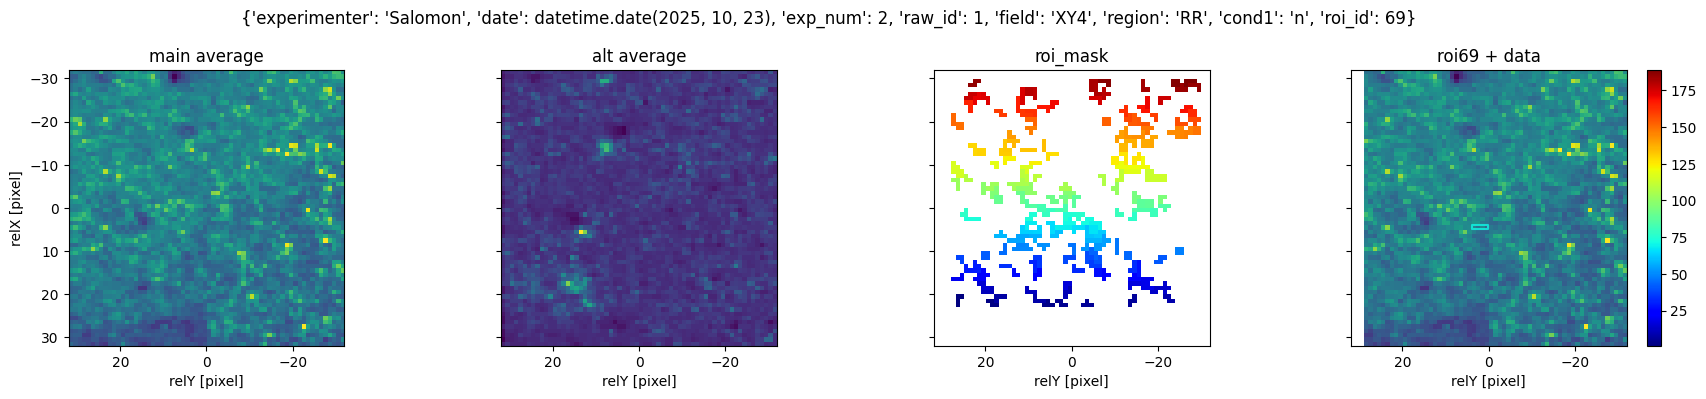

In [44]:
# Plot ROI
(Roi() & {"date": date, "field": picked_field, "roi_id": picked_roi, "cond2": "C1"}).plot1()
plt.savefig(f"plots/20251023/gchirp/M1_RR_{picked_field}_gChirp_ROI{picked_roi}_image.png",
           dpi=300,
           bbox_inches="tight")

# Plot average traces, gChirp
## Prepare data

In [45]:
# Filter dataset for specific date
Averages_20251023 = Averages() & {"date": date, "stim_name": "gChirp"}
Averages_20251023

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,1,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,2,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,4,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,5,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,7,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,8,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,9,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,10,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=


In [46]:
# Check database entry for specific ROI and field
Averages_20251023 & {"roi_id": picked_roi, "field": picked_field}

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,69,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,DETANO,69,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=


In [48]:
# Fetsch the two arrays
average_c1 = (Averages_20251023 & {"roi_id": picked_roi, "field": picked_field, "cond2": "C1"}).fetch1("average_norm")
average_treatment = (Averages_20251023 & {"roi_id": picked_roi, "field": picked_field, "cond2": conditions[1]}).fetch1("average_norm")
print(f"C1 array: {average_c1}")
print(f"Treated array: {average_treatment}")

C1 array: [-0.142451   -0.13834696 -0.13424292 ... -0.21580608 -0.21580608
 -0.21580608]
Treated array: [-0.13317528 -0.13321438 -0.13325348 ... -0.23989945 -0.23989945
 -0.23989945]


In [49]:
# Compute minimum length of both arrays
min_len = min(len(average_c1), len(average_treatment))
print(f"Min length arrays: {min_len}")

# Bring both arrays to the same length if different
# Sometime after normalisation arrays can differe by one entry --> would lead to error message if delta would be computed
average_c1 = average_c1[:min_len]
average_treatment = average_treatment[:min_len]

# Compute difference
delta_average_norm = average_c1 - average_treatment
print(f"Length of delta arrays: {len(delta_average_norm)}")
print(f"Delta_treatments: {delta_average_norm}")

Min length arrays: 16516
Length of delta arrays: 16516
Delta_treatments: [-0.00927573 -0.00513258 -0.00098944 ...  0.02409337  0.02409337
  0.02409337]


## Compute correlation between traces

In [50]:
correlation_c1_treatment = np.corrcoef(average_c1, average_treatment)
correlation_c1_treatment = np.round(correlation_c1_treatment[0, 1], 2)
print(f"Correlation between both treatments: {correlation_c1_treatment}")

Correlation between both treatments: 0.87


## Plot data

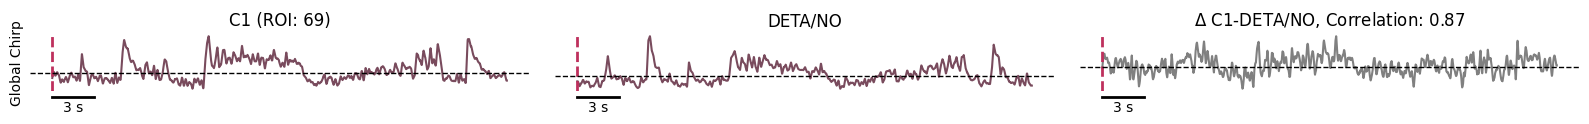

In [51]:
fig, axs = plt.subplots(1, 3, figsize=(20,0.75))

axs[0].plot(average_c1, color="#794b5d")
axs[1].plot(average_treatment, color="#794b5d")
axs[2].plot(delta_average_norm, color="grey")

for i in range(3):
    
    # After plotting inside your loop
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['bottom'].set_visible(False)
    
    # Remove ticks and labels
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_xlabel("")
    #axs[i].set_ylabel(conditions[i])

    axs[i].axvline(
        x=0,
        color="#be305d",
        linestyle="--",
        linewidth=2)

    axs[i].axhline(y=0,
                   color="black",
                   linestyle="--",
                   linewidth=1)

    # Example: add a scale bar of 5 seconds (adjust as needed)
    scalebar_len = 1500  # seconds
    scalebar_text = 3
    x_start = 0       # where the bar starts on the x-axis
    y_pos = -0.1     # relative position (in axis coords)
    
    # Draw horizontal bar
    axs[i].plot([x_start, x_start + scalebar_len],
                [y_pos, y_pos], color="black", lw=2, clip_on=False,
                transform=axs[i].get_xaxis_transform())
    
    # Annotate it
    axs[i].text(x_start + scalebar_len/2, y_pos - 0.05,
                f"{scalebar_text} s", ha="center", va="top",
                transform=axs[i].get_xaxis_transform())

# Define axis titles
axs[0].set_title(f"C1 (ROI: {picked_roi})")
axs[0].set_ylabel("Global Chirp")

if conditions[1] == "C2":
    axs[1].set_title("C2")
elif conditions[1] == "DETANO":
    axs[1].set_title("DETA/NO")
    
if conditions[1] == "C2":
    axs[2].set_title(rf"$\Delta$ C1-C2, Correlation: {correlation_c1_treatment}")
elif conditions[1] == "DETANO":
    axs[2].set_title(rf"$\Delta$ C1-DETA/NO, Correlation: {correlation_c1_treatment}")

plt.subplots_adjust(wspace=0.05)

plt.savefig(f"plots/20251023/gchirp/M1_RR_{picked_field}_gChirp_ROI{picked_roi}_deltaAVG.png",
           dpi=300,
           bbox_inches="tight")

In [52]:
# Filter dataset for specific date
Averages_filtered = Averages() & {"date": date, "field": picked_field, "roi_id": picked_roi}
Averages_filtered

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,69,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,DETANO,69,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,lChirp,C1,69,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,lChirp,DETANO,69,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,movingbar,C1,69,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,movingbar,DETANO,69,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=


In [53]:
# Fetch relevant fields
stim_names, cond2s, averages = Averages_filtered.fetch('stim_name', 'cond2', 'average_norm')
print(stim_names)
print(cond2s)
print(averages)

['gChirp' 'gChirp' 'lChirp' 'lChirp' 'movingbar' 'movingbar']
['C1' 'DETANO' 'C1' 'DETANO' 'C1' 'DETANO']
[array([-0.142451  , -0.13834696, -0.13424292, ..., -0.21580608,
        -0.21580608, -0.21580608], shape=(16516,))
 array([-0.13317528, -0.13321438, -0.13325348, ..., -0.23989945,
        -0.23989945, -0.23989945], shape=(16516,))
 array([-0.01843999, -0.02019608, -0.02224508, ...,  0.02983257,
         0.02983257,  0.02983257], shape=(16516,))
 array([-0.13080914, -0.12977942, -0.12874969, ..., -0.14184172,
        -0.14184172, -0.14184172], shape=(16516,))
 array([0.10316174, 0.10384212, 0.1045225 , ..., 0.08354457, 0.08309253,
        0.08264049], shape=(2028,))
 array([-0.06853348, -0.06901715, -0.06961149, ..., -0.08729967,
        -0.0874521 , -0.08754022], shape=(2028,))               ]


In [54]:
# Convert to a structured dictionary: stim_name → {cond2: average_norm}
data = {}
for stim, cond, avg in zip(stim_names, cond2s, averages):
    if stim not in data:
        data[stim] = {}
    data[stim][cond] = avg

data

{'gChirp': {'C1': array([-0.142451  , -0.13834696, -0.13424292, ..., -0.21580608,
         -0.21580608, -0.21580608], shape=(16516,)),
  'DETANO': array([-0.13317528, -0.13321438, -0.13325348, ..., -0.23989945,
         -0.23989945, -0.23989945], shape=(16516,))},
 'lChirp': {'C1': array([-0.01843999, -0.02019608, -0.02224508, ...,  0.02983257,
          0.02983257,  0.02983257], shape=(16516,)),
  'DETANO': array([-0.13080914, -0.12977942, -0.12874969, ..., -0.14184172,
         -0.14184172, -0.14184172], shape=(16516,))},
 'movingbar': {'C1': array([0.10316174, 0.10384212, 0.1045225 , ..., 0.08354457, 0.08309253,
         0.08264049], shape=(2028,)),
  'DETANO': array([-0.06853348, -0.06901715, -0.06961149, ..., -0.08729967,
         -0.0874521 , -0.08754022], shape=(2028,))}}

In [55]:
# Sort stimuli and conditions for consistent ordering
stimuli = sorted(data.keys())

# --- Determine condition labels automatically ---
# Collect all unique cond2 values
all_conditions = sorted({c for conds in data.values() for c in conds.keys()})

print(stimuli)
print(all_conditions)

['gChirp', 'lChirp', 'movingbar']
['C1', 'DETANO']


In [56]:
# Identify baseline and treatment labels
if "C1" in all_conditions and "C2" in all_conditions:
    cond_baseline, cond_treatment = "C1", "C2"
elif "C1" in all_conditions and "DETANO" in all_conditions:
    cond_baseline, cond_treatment = "C1", "DETANO"
else:
    raise ValueError(f"Unexpected condition labels found: {all_conditions}")

print(f"Using conditions: baseline = {cond_baseline}, treatment = {cond_treatment}")

Using conditions: baseline = C1, treatment = DETANO


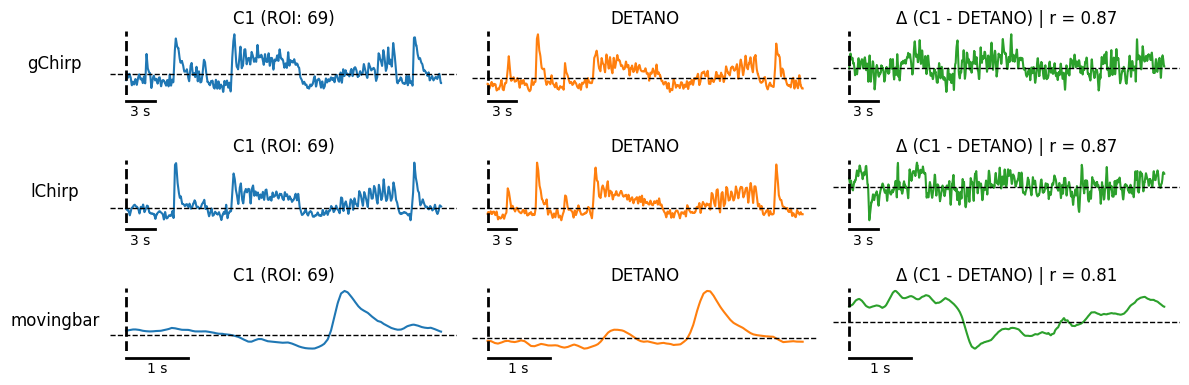

In [62]:
fig, axes = plt.subplots(len(stimuli), 3, figsize=(12, 4), sharex=False, sharey=False)
if len(stimuli) == 1:
    axes = axes[np.newaxis, :]

# --- Loop through stimuli ---
for i, stim in enumerate(stimuli):
    cond1_trace = data[stim].get(cond_baseline)
    cond2_trace = data[stim].get(cond_treatment)

    if cond1_trace is not None and cond2_trace is not None:
        min_len = min(len(cond1_trace), len(cond2_trace))
        cond1_trace = cond1_trace[:min_len]
        cond2_trace = cond2_trace[:min_len]
        delta = cond1_trace - cond2_trace
        corr_r = np.corrcoef(cond1_trace, cond2_trace)[0, 1]
    else:
        continue

    # --- Plot each column ---
    for j, (trace, title) in enumerate([
        (cond1_trace, cond_baseline),
        (cond2_trace, cond_treatment),
        (delta, f"Δ ({cond_baseline} - {cond_treatment})")
    ]):
        ax = axes[i, j]
        color = ["#1f77b4", "#ff7f0e", "#2ca02c"][j]
        ax.plot(trace, color=color, lw=1.5)

        # Modify titles dynamically
        if j == 0:
            # Add ROI info to the first column title
            ax.set_title(f"{title} (ROI: {roi_id})")
        elif j == 2:
            # Add correlation coefficient to the delta plot
            ax.set_title(f"{title} | r = {corr_r:.2f}")
        else:
            ax.set_title(title)

        # Label rows with stimulus name
        if j == 0:
            ax.set_ylabel(stim, rotation=0, labelpad=40, fontsize=12, va='center')

        # --- Style: remove boxes and ticks ---
        for spine in ['top', 'right', 'left', 'bottom']:
            ax.spines[spine].set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")

        # --- Add trigger and baseline lines ---
        ax.axvline(x=0, color="black", linestyle="--", linewidth=2)
        ax.axhline(y=0, color="black", linestyle="--", linewidth=1)

        # --- Add scale bars (stimulus-specific) ---
        if stim in ["gChirp", "lChirp"]:
            samples_per_s = 500
            scale_seconds = 3
        elif stim == "movingbar":
            samples_per_s = 400
            scale_seconds = 1
        else:
            samples_per_s = 500
            scale_seconds = 1

        scalebar_len = samples_per_s * scale_seconds
        x_start = 0
        y_pos = -0.1  # relative axis position for scale bar

        # Draw scale bar
        ax.plot([x_start, x_start + scalebar_len],
                [y_pos, y_pos],
                color="black", lw=2, clip_on=False,
                transform=ax.get_xaxis_transform())

        # Annotate the scale bar
        ax.text(x_start + scalebar_len / 2, y_pos - 0.05,
                f"{scale_seconds} s",
                ha="center", va="top",
                transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()

# Plot average traces, lChirp
## Prepare data

In [139]:
# Filter dataset for specific date and stimulus
Averages_20251023 = Averages() & {"date": date, "stim_name": "lChirp"}
Averages_20251023

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,1,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,2,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,4,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,5,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,7,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,8,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,9,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,10,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=


In [140]:
# Check database entry for specific ROI and field
Averages_20251023 & {"roi_id": picked_roi, "field": picked_field}

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes
Salomon,2025-10-23,2,1,XY3,RR,n,lChirp,C1,107,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY3,RR,n,lChirp,C2,107,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=


In [141]:
# Fetsch the two arrays
average_c1 = (Averages_20251023 & {"roi_id": picked_roi, "field": picked_field, "cond2": "C1"}).fetch1("average_norm")
average_treatment = (Averages_20251023 & {"roi_id": picked_roi, "field": picked_field, "cond2": "C2"}).fetch1("average_norm")
print(f"C1 array: {average_c1}")
print(f"Treated array: {average_treatment}")

C1 array: [0.52162876 0.52472154 0.52781431 ... 0.44532682 0.44532682 0.44532682]
Treated array: [0.14361377 0.14510337 0.14659296 ... 0.18228926 0.18228926 0.18228926]


In [142]:
# Compute minimum length of both arrays
min_len = min(len(average_c1), len(average_treatment))
print(f"Min length arrays: {min_len}")

# Bring both arrays to the same length if different
# Sometime after normalisation arrays can differe by one entry --> would lead to error message if delta would be computed
average_c1 = average_c1[:min_len]
average_treatment = average_treatment[:min_len]

# Compute difference
delta_average_norm = average_c1 - average_treatment
print(f"Length of delta arrays: {len(delta_average_norm)}")
print(f"Delta_treatments: {delta_average_norm}")

Min length arrays: 16515
Length of delta arrays: 16515
Delta_treatments: [0.37801498 0.37961817 0.38122136 ... 0.26303757 0.26303757 0.26303757]


## Compute correlation between traces

In [143]:
correlation_c1_treatment = np.corrcoef(average_c1, average_treatment)
correlation_c1_treatment = np.round(correlation_c1_treatment[0, 1], 2)
print(f"Correlation between both treatments: {correlation_c1_treatment}")

Correlation between both treatments: -0.31


## Plot data

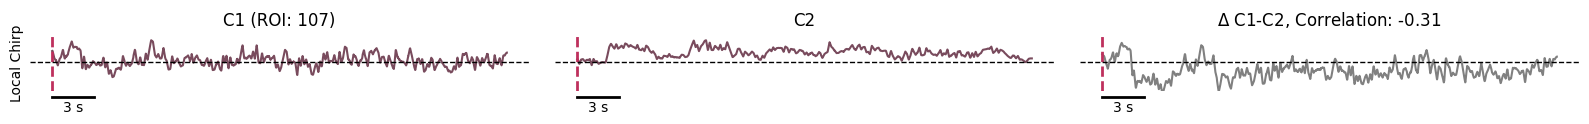

In [146]:
fig, axs = plt.subplots(1, 3, figsize=(20,0.75))

axs[0].plot(average_c1, color="#794b5d")
axs[1].plot(average_treatment, color="#794b5d")
axs[2].plot(delta_average_norm, color="grey")

for i in range(3):

    axs[i].set_ylim(-1.3, 1.3)
    
    # After plotting inside your loop
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['bottom'].set_visible(False)
    
    # Remove ticks and labels
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_xlabel("")
    #axs[i].set_ylabel(conditions[i])

    axs[i].axvline(
        x=0,
        color="#be305d",
        linestyle="--",
        linewidth=2)

    axs[i].axhline(y=0,
                   color="black",
                   linestyle="--",
                   linewidth=1)

    # Example: add a scale bar of 5 seconds (adjust as needed)
    scalebar_len = 1500  # seconds
    scalebar_text = 3
    x_start = 0       # where the bar starts on the x-axis
    y_pos = -0.1     # relative position (in axis coords)
    
    # Draw horizontal bar
    axs[i].plot([x_start, x_start + scalebar_len],
                [y_pos, y_pos], color="black", lw=2, clip_on=False,
                transform=axs[i].get_xaxis_transform())
    
    # Annotate it
    axs[i].text(x_start + scalebar_len/2, y_pos - 0.05,
                f"{scalebar_text} s", ha="center", va="top",
                transform=axs[i].get_xaxis_transform())

# Define axis titles
axs[0].set_title(f"C1 (ROI: {picked_roi})")
axs[0].set_ylabel(f"Local Chirp")

if conditions[1] == "C2":
    axs[1].set_title("C2")
elif conditions[1] == "DETANO":
    axs[1].set_title("DETA/NO")
    
if conditions[1] == "C2":
    axs[2].set_title(rf"$\Delta$ C1-C2, Correlation: {correlation_c1_treatment}")
elif conditions[1] == "DETANO":
    axs[2].set_title(rf"$\Delta$ C1-DETA/NO, Correlation: {correlation_c1_treatment}")
    
plt.subplots_adjust(wspace=0.05)

plt.savefig(f"plots/20251023/lchirp/M1_RR_{picked_field}_lChirp_ROI{picked_roi}_deltaAVG.png",
           dpi=300,
           bbox_inches="tight")

# Plot average traces, Moving Bars
## Prepare data

In [131]:
# Filter dataset for specific date
Averages_20251023 = Averages() & {"date": date, "stim_name": "movingbar"}
Averages_20251023

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,1,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,2,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,4,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,5,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,7,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,8,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,9,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,1,1,XY7,LR,t,movingbar,C1,10,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=


In [132]:
# Check database entry for specific ROI and field
Averages_20251023 & {"roi_id": picked_roi, "field": picked_field}

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes
Salomon,2025-10-23,2,1,XY3,RR,n,movingbar,C1,107,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY3,RR,n,movingbar,C2,107,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=


In [133]:
# Fetsch the two arrays
average_c1 = (Averages_20251023 & {"roi_id": picked_roi, "field": picked_field, "cond2": "C1"}).fetch1("average_norm")
average_treatment = (Averages_20251023 & {"roi_id": picked_roi, "field": picked_field, "cond2": "C2"}).fetch1("average_norm")
print(f"C1 array: {average_c1}")
print(f"Treated array: {average_treatment}")

C1 array: [-0.03245619 -0.03076619 -0.02907618 ... -0.13441971 -0.13241157
 -0.13040343]
Treated array: [-0.77290882 -0.77053706 -0.76816547 ... -0.85003788 -0.84909312
 -0.84814835]


In [134]:
# Compute minimum length of both arrays
min_len = min(len(average_c1), len(average_treatment))
print(f"Min length arrays: {min_len}")

# Bring both arrays to the same length if different
# Sometime after normalisation arrays can differe by one entry --> would lead to error message if delta would be computed
average_c1 = average_c1[:min_len]
average_treatment = average_treatment[:min_len]

# Compute difference
delta_average_norm = average_c1 - average_treatment
print(f"Length of delta arrays: {len(delta_average_norm)}")
print(f"Delta_treatments: {delta_average_norm}")

Min length arrays: 2028
Length of delta arrays: 2028
Delta_treatments: [0.74045262 0.73977087 0.73908928 ... 0.71561816 0.71668154 0.71774492]


## Compute correlation between traces

In [135]:
correlation_c1_treatment = np.corrcoef(average_c1, average_treatment)
correlation_c1_treatment = np.round(correlation_c1_treatment[0, 1], 2)
print(f"Correlation between both treatments: {correlation_c1_treatment}")

Correlation between both treatments: -0.59


## Plot data

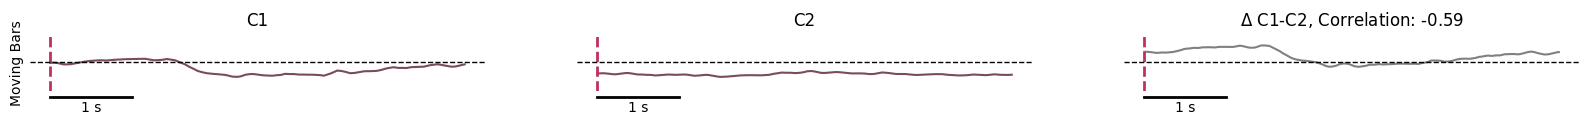

In [136]:
fig, axs = plt.subplots(1, 3, figsize=(20,0.75))

axs[0].plot(average_c1, color="#794b5d")
axs[1].plot(average_treatment, color="#794b5d")
axs[2].plot(delta_average_norm, color="grey")

for i in range(3):

    axs[i].set_ylim(-2, 2)
    
    # After plotting inside your loop
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['bottom'].set_visible(False)
    
    # Remove ticks and labels
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_xlabel("")
    #axs[i].set_ylabel(conditions[i])

    axs[i].axvline(
        x=0,
        color="#be305d",
        linestyle="--",
        linewidth=2)

    axs[i].axhline(y=0,
                   color="black",
                   linestyle="--",
                   linewidth=1)

    # Example: add a scale bar of 5 seconds (adjust as needed)
    scalebar_len = 400  # seconds
    scalebar_text = 1
    x_start = 0       # where the bar starts on the x-axis
    y_pos = -0.1     # relative position (in axis coords)
    
    # Draw horizontal bar
    axs[i].plot([x_start, x_start + scalebar_len],
                [y_pos, y_pos], color="black", lw=2, clip_on=False,
                transform=axs[i].get_xaxis_transform())
    
    # Annotate it
    axs[i].text(x_start + scalebar_len/2, y_pos - 0.05,
                f"{scalebar_text} s", ha="center", va="top",
                transform=axs[i].get_xaxis_transform())

# Define axis titles
axs[0].set_title(f"C1 (ROI: {picked_roi})")
axs[0].set_ylabel("Moving Bars")

if conditions[1] == "C2":
    axs[1].set_title("C2")
elif conditions[1] == "DETANO":
    axs[1].set_title("DETA/NO")
    
if conditions[1] == "C2":
    axs[2].set_title(rf"$\Delta$ C1-C2, Correlation: {correlation_c1_treatment}")
elif conditions[1] == "DETANO":
    axs[2].set_title(rf"$\Delta$ C1-DETA/NO, Correlation: {correlation_c1_treatment}")

plt.subplots_adjust(wspace=0.05)

plt.savefig(f"plots/20251023/mb/M1_RR_{picked_field}_mb_ROI{picked_roi}_deltaAVG.png",
           dpi=300,
           bbox_inches="tight")